# Monocle3 — *C. elegans* L2 (Python port)

Python port of the R vignette `c_elegans_L2_v2.ipynb`. Covers preprocessing, `plot_pc_variance_explained`, batch correction, clustering, marker detection, partition → cell-type assignment, and Garnett marker file generation on the Cao et al. 2017 L2 worm atlas (42035 cells × 20271 genes).


## 1. Setup

In [1]:
import numpy as np
import pandas as pd

import monocle3 as m3
print('monocle3-python', m3.__version__)

monocle3-python 1.4.26+4f4239a


In [2]:
%config InlineBackend.figure_format = 'retina'

## 2. Load L2 worm data (Cao et al. 2017)

In [3]:
adata = m3.load_cao_l2()
m3.estimate_size_factors(adata)
adata

AnnData object with n_obs × n_vars = 42035 × 20271
    obs: 'plate', 'cao_cluster', 'cao_cell_type', 'cao_tissue', 'Size_Factor'
    var: 'gene_short_name'

## 3. Preprocess (size-factor + PCA) and inspect variance

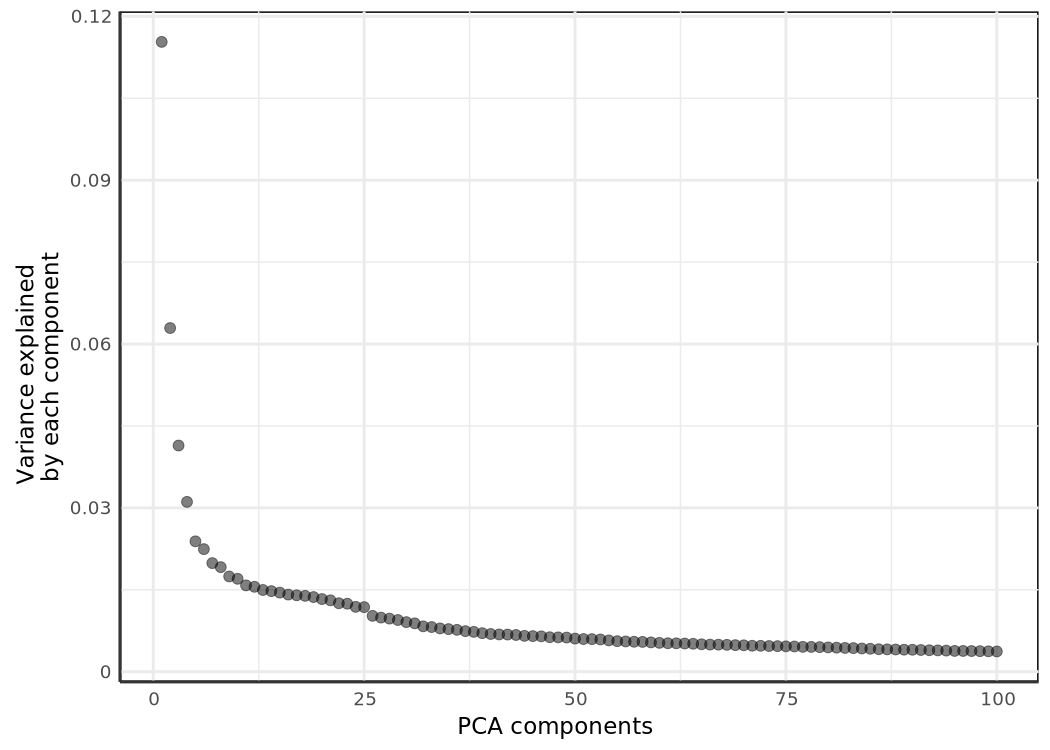

In [4]:
m3.preprocess_cds(adata, num_dim=100)
m3.plot_pc_variance_explained(adata)

## 4. UMAP (before batch correction) — shows the `plate` batch effect

/tmp/ipykernel_23775/190202095.py:2: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='cao_cell_type')


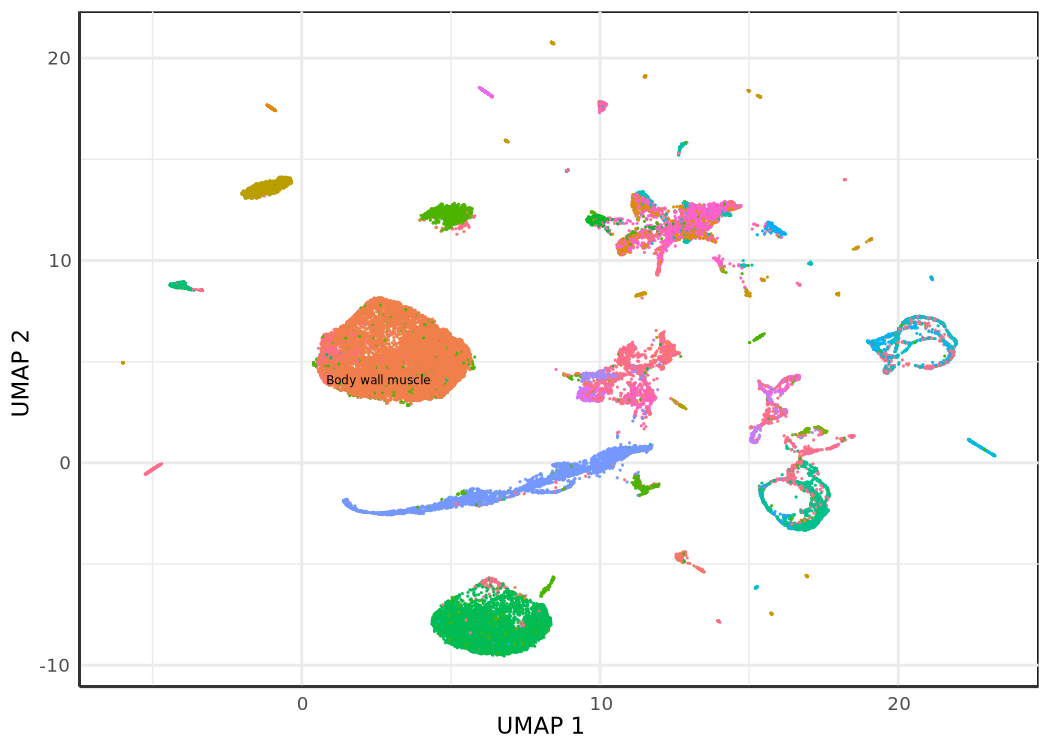

In [5]:
m3.reduce_dimension(adata)
m3.plot_cells(adata, color_cells_by='cao_cell_type')

/tmp/ipykernel_23775/1269585316.py:1: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='plate', label_cell_groups=False)


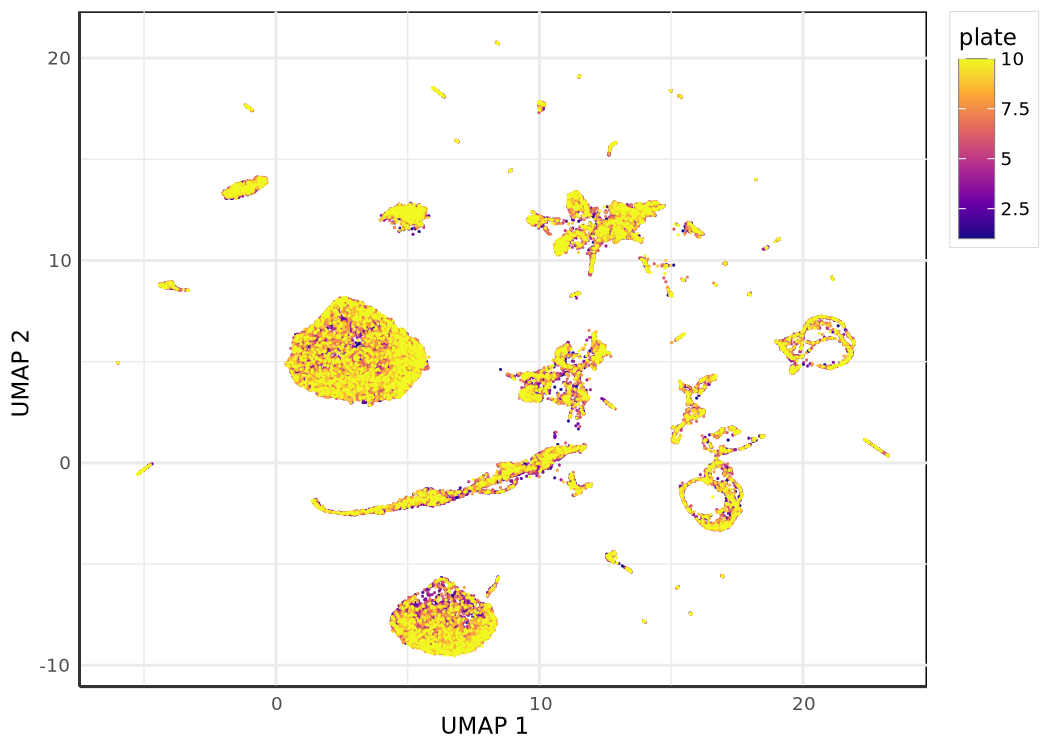

In [6]:
m3.plot_cells(adata, color_cells_by='plate', label_cell_groups=False)

/scratch/groups/xiaojie/nianping_scratch/Test_ggplot2/ggplot2_py/ggplot2_py/layer.py:892: UserWarning: Ignoring unknown parameters: color
  cli_warn(
/tmp/ipykernel_23775/3659014439.py:1: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, genes=['cpna-2', 'egl-21', 'ram-2', 'inos-1'])


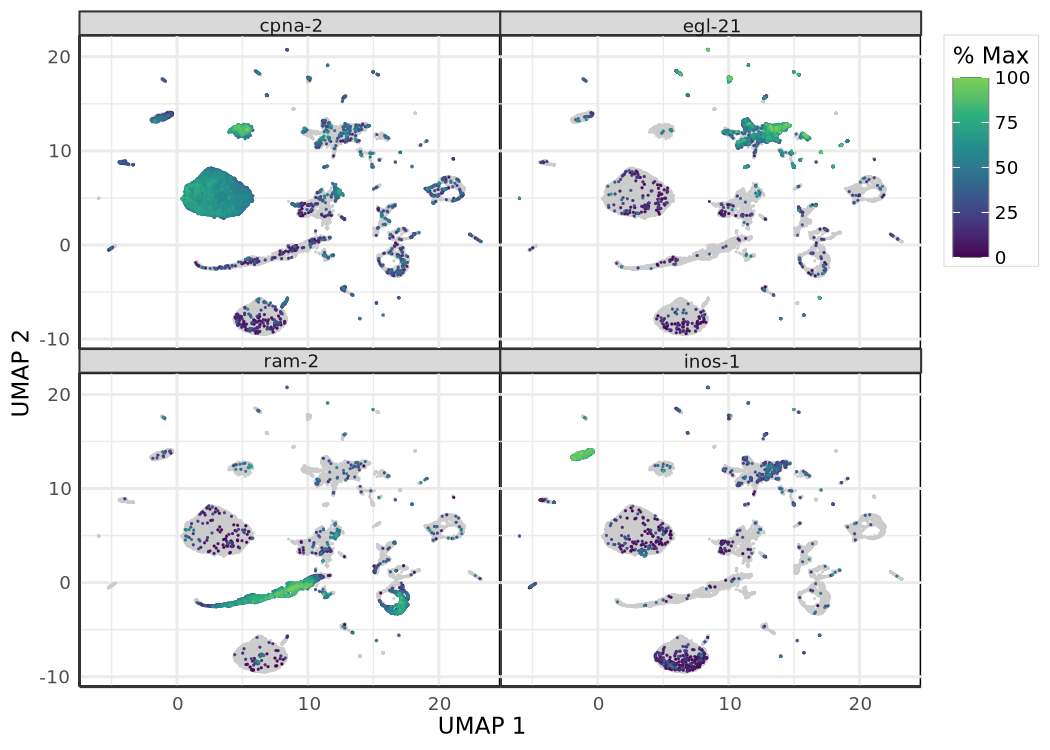

In [7]:
m3.plot_cells(adata, genes=['cpna-2', 'egl-21', 'ram-2', 'inos-1'])

## 5. Align on `plate` and re-embed — batch effect is removed

Found 100 genes among all datasets
[[0.         0.65141879 0.42735043 0.42074364 0.50954012 0.43395303
  0.38625245 0.3906628  0.32289628 0.29847054]
 [0.         0.         0.42529915 0.40562956 0.5277708  0.45136969
  0.39733601 0.39138849 0.32998241 0.31466487]
 [0.         0.         0.         0.47487179 0.42222222 0.37367521
  0.33162393 0.31179487 0.25230769 0.24991453]
 [0.         0.         0.         0.         0.42402402 0.38648649
  0.32762763 0.31351351 0.26606607 0.25645646]
 [0.         0.         0.         0.         0.         0.62577921
  0.56344259 0.52007741 0.50447501 0.4925776 ]
 [0.         0.         0.         0.         0.         0.
  0.58448348 0.56119981 0.52433966 0.52316689]
 [0.         0.         0.         0.         0.         0.
  0.         0.59966134 0.59681292 0.56747638]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.60008732 0.59559154]
 [0.         0.         0.         0.         0.         0.
  0.     

/tmp/ipykernel_23775/2194241184.py:2: UserWarning: No preprocess_method specified, and aligned coordinates have been computed previously. Using preprocess_method = 'Aligned'
  m3.reduce_dimension(adata, cores=1)
/tmp/ipykernel_23775/2194241184.py:3: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='plate', label_cell_groups=False)


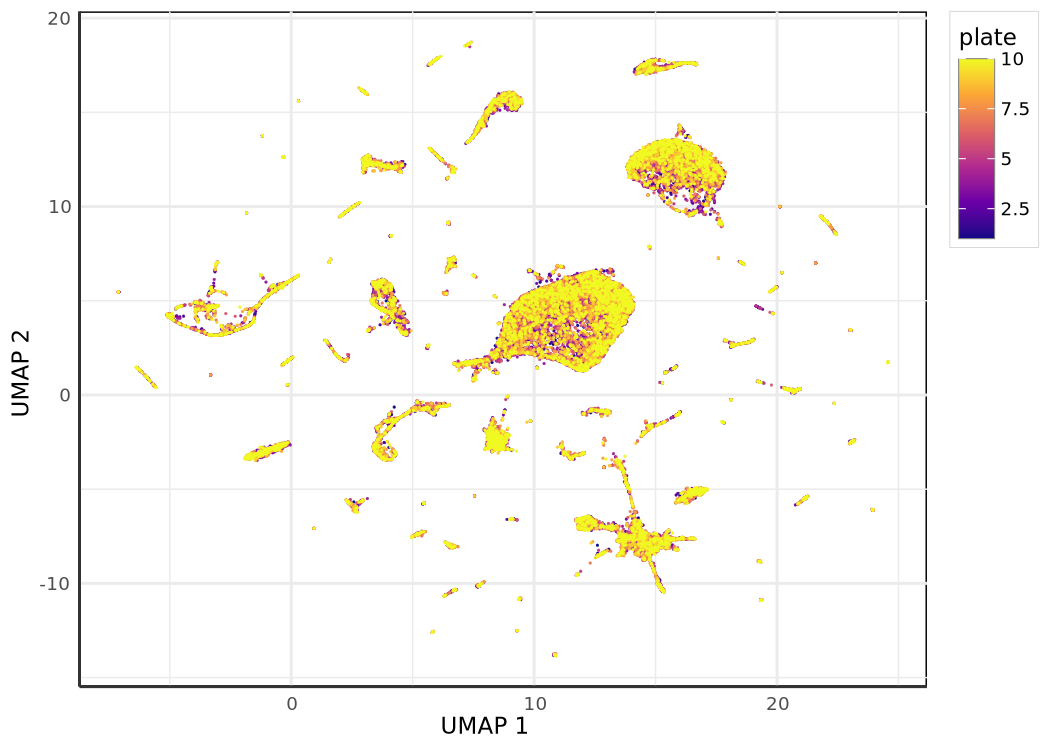

In [8]:
m3.align_cds(adata, alignment_group='plate')
m3.reduce_dimension(adata, cores=1)
m3.plot_cells(adata, color_cells_by='plate', label_cell_groups=False)

/tmp/ipykernel_23775/1995899236.py:1: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='cao_cell_type', label_groups_by_cluster=False)


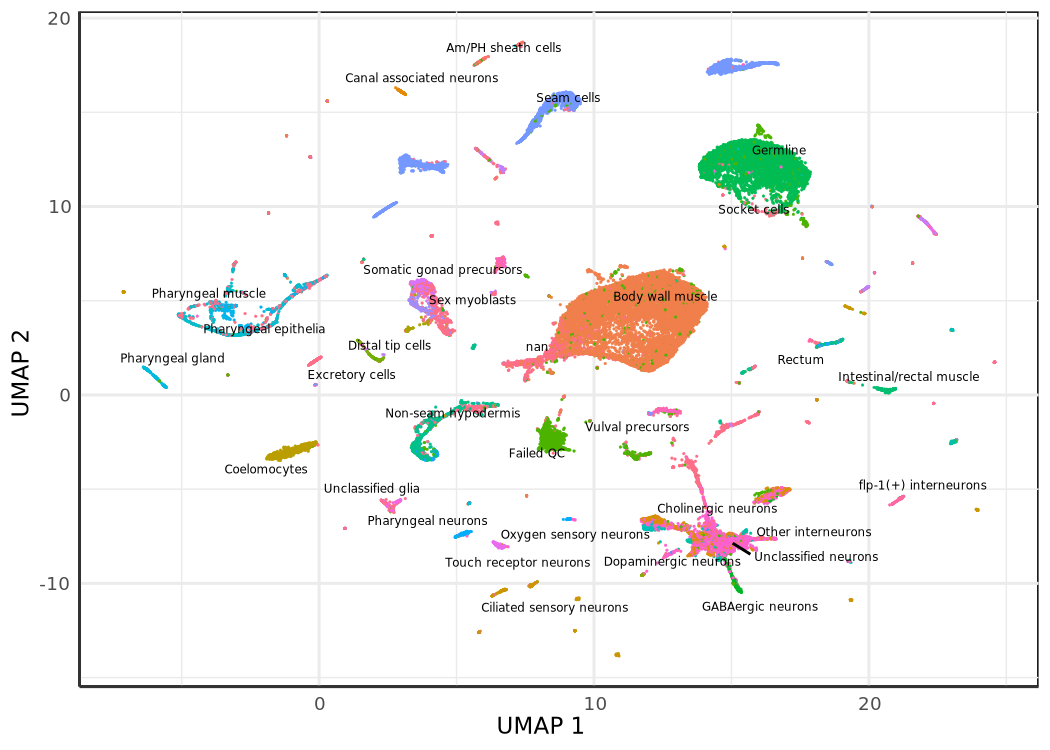

In [9]:
m3.plot_cells(adata, color_cells_by='cao_cell_type', label_groups_by_cluster=False)

## 6. Cluster cells + partition-level structure

/tmp/ipykernel_23775/208673322.py:2: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='partition', group_cells_by='partition')


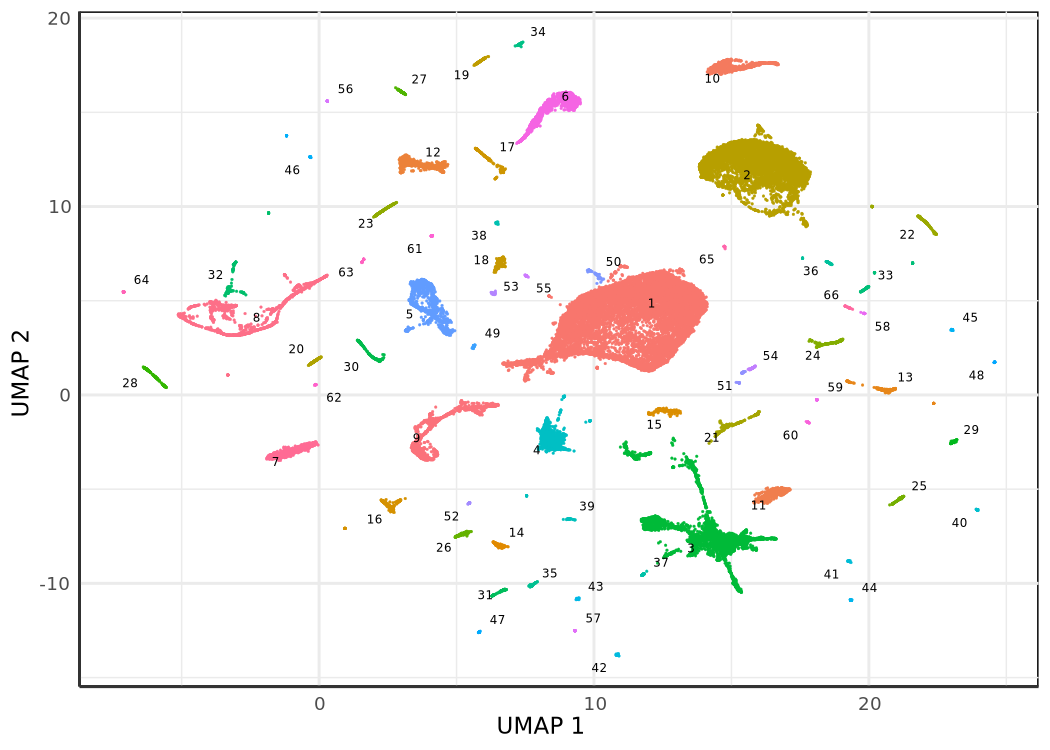

In [10]:
m3.cluster_cells(adata)
m3.plot_cells(adata, color_cells_by='partition', group_cells_by='partition')

/tmp/ipykernel_23775/3228641365.py:1: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='cao_cell_type')


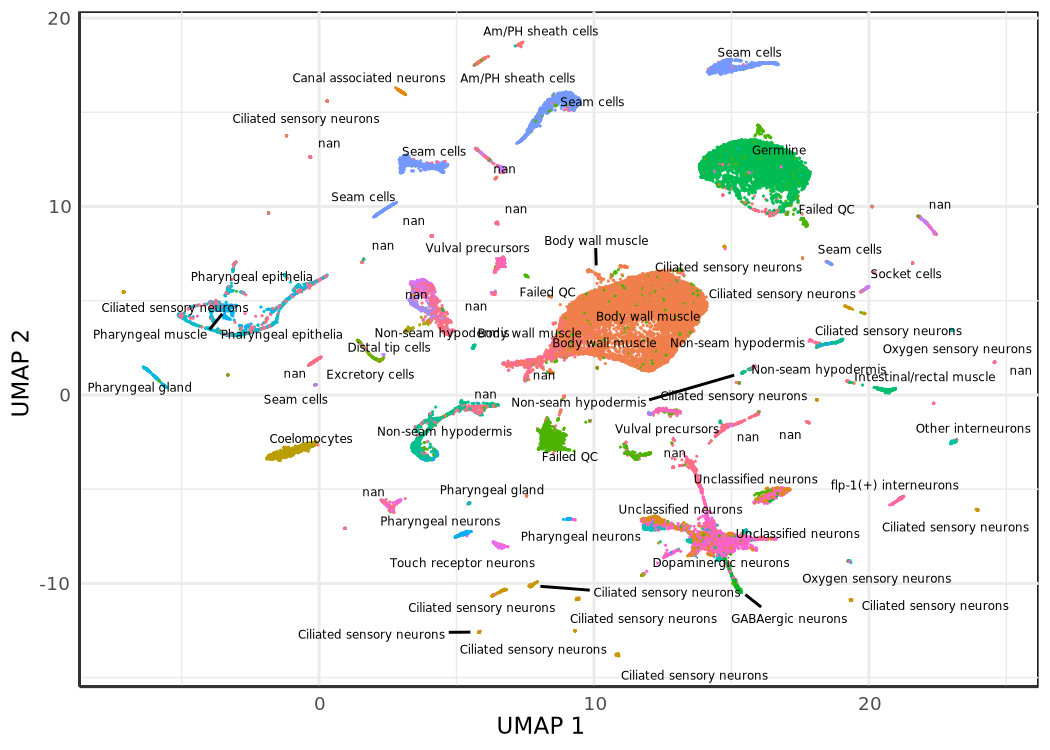

In [11]:
m3.plot_cells(adata, color_cells_by='cao_cell_type')

## 7. Top marker genes per partition

In [ ]:
marker_test_res = m3.top_markers(
    adata, group_cells_by='partition', reference_cells=1000, cores=8,
)
top_specific_markers = (
    marker_test_res.query('fraction_expressing >= 0.10')
    .sort_values('pseudo_R2', ascending=False)
    .groupby('cell_group', as_index=False)
    .head(3)
)
top_specific_marker_ids = pd.unique(top_specific_markers['gene_id']).tolist()

m3.plot_genes_by_group(
    adata, top_specific_marker_ids,
    group_cells_by='partition',
    ordering_type='cluster_row_col',
    max_size=3,
)

/scratch/groups/xiaojie/nianping_scratch/Test_Monocle3/monocle3-python/monocle3/find_markers.py:200: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


## 8. Auto-label partitions by majority `cao_cell_type`

The upstream tutorial hand-recodes partition IDs 1–34 into cell-type names. Our clustering won't reproduce those IDs, so we pick the majority `cao_cell_type` per partition programmatically.

In [ ]:
parts = m3.partitions(adata).astype(str)
cross = pd.crosstab(parts, adata.obs['cao_cell_type'].astype(str))
cross_prop = cross.div(cross.sum(axis=1), axis=0).fillna(0)
partition_to_type = cross_prop.idxmax(axis=1).to_dict()

adata.obs['assigned_cell_type'] = parts.map(partition_to_type)
m3.plot_cells(adata, group_cells_by='partition', color_cells_by='assigned_cell_type')

## 9. Re-run `top_markers` on `assigned_cell_type` → Garnett marker file

In [ ]:
assigned_mask = adata.obs['assigned_cell_type'].notna().to_numpy()
assigned_adata = adata[assigned_mask].copy()
assigned_type_marker_test_res = m3.top_markers(
    assigned_adata,
    group_cells_by='assigned_cell_type',
    reference_cells=1000, cores=8,
)

garnett_markers = (
    assigned_type_marker_test_res.query(
        'marker_test_q_value < 0.01 & specificity >= 0.5'
    )
    .sort_values('marker_score', ascending=False)
    .groupby('cell_group', as_index=False)
    .head(5)
)
# Remove duplicates that mark multiple groups.
garnett_markers = garnett_markers.groupby('gene_short_name', as_index=False) \
    .filter(lambda g: len(g) == 1)

m3.generate_garnett_marker_file(garnett_markers, file='./marker_file.txt')